TensorFlow: 2.13.1
Early_blight : 30 images
Late_blight : 30 images
healthy : 30 images
Dataset ready
Found 90 files belonging to 3 classes.
Using 63 files for training.
Found 90 files belonging to 3 classes.
Using 27 files for validation.
Classes: ['Early_blight', 'Late_blight', 'healthy']
Train batches: 4
Validation batches: 1
Test batches: 1


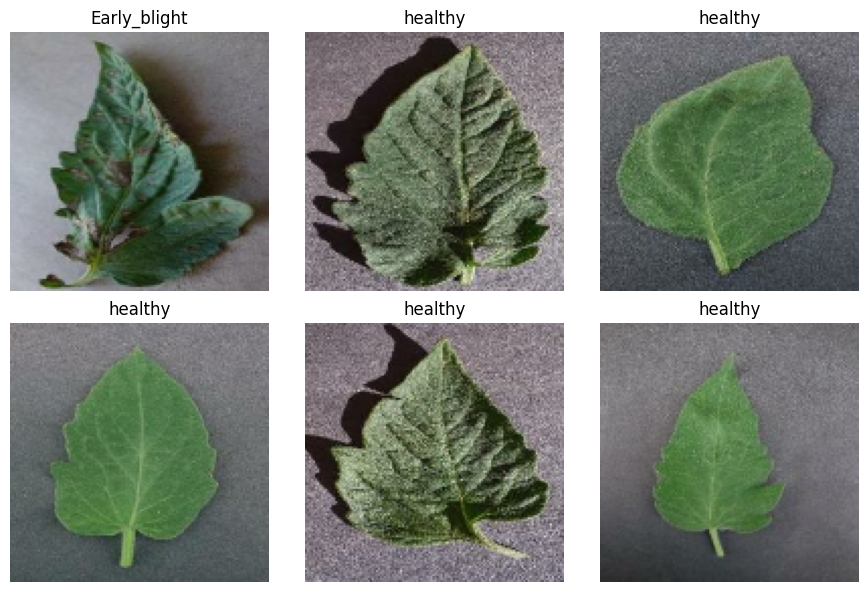


CNN TRAINING
Epoch 1/3
4/4 [==============================] - 0s 75ms/step - loss: 1.2317 - accuracy: 0.2381 - val_loss: 1.0873 - val_accuracy: 0.0000e+00
Epoch 2/3
4/4 [==============================] - 0s 62ms/step - loss: 1.0893 - accuracy: 0.4603 - val_loss: 1.1210 - val_accuracy: 0.0000e+00
Epoch 3/3
4/4 [==============================] - 0s 62ms/step - loss: 1.0821 - accuracy: 0.3968 - val_loss: 1.0156 - val_accuracy: 0.6875

MOBILENETV2 TRAINING
Epoch 1/3
4/4 [==============================] - 1s 101ms/step - loss: 1.3217 - accuracy: 0.4286 - val_loss: 0.3716 - val_accuracy: 0.9375
Epoch 2/3
4/4 [==============================] - 0s 36ms/step - loss: 0.5491 - accuracy: 0.7937 - val_loss: 0.2510 - val_accuracy: 0.9375
Epoch 3/3
4/4 [==============================] - 0s 37ms/step - loss: 0.2876 - accuracy: 0.9206 - val_loss: 0.1703 - val_accuracy: 0.9375

MODEL PERFORMANCE
CNN Test Accuracy: 100.0 %
MobileNetV2 Test Accuracy: 100.0 %


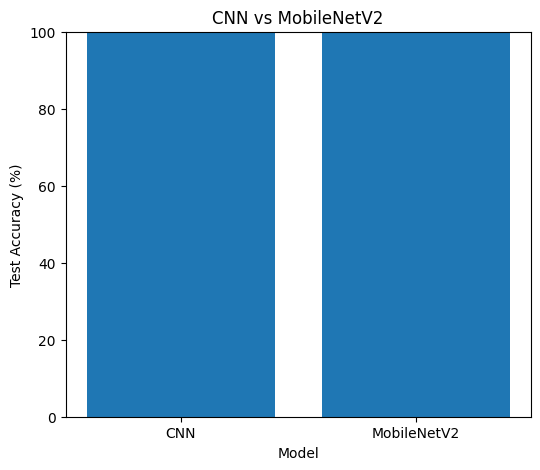


CLASSIFICATION REPORT
              precision    recall  f1-score   support

Early_blight       0.00      0.00      0.00         0
 Late_blight       0.00      0.00      0.00         0
     healthy       1.00      1.00      1.00        11

    accuracy                           1.00        11
   macro avg       0.33      0.33      0.33        11
weighted avg       1.00      1.00      1.00        11



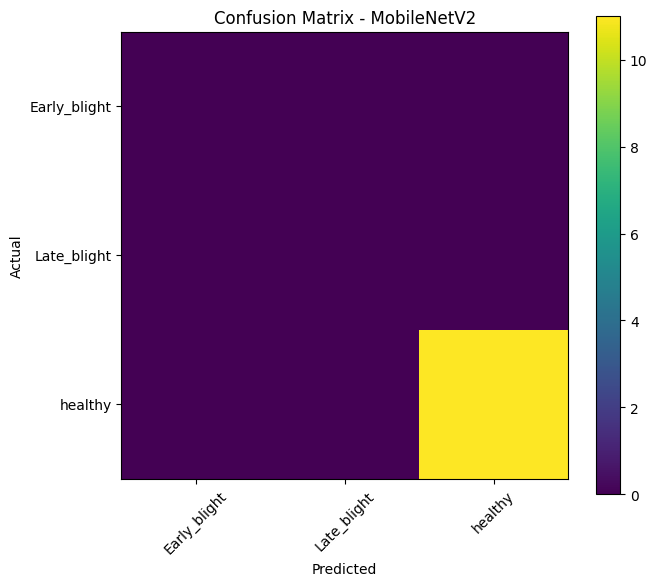

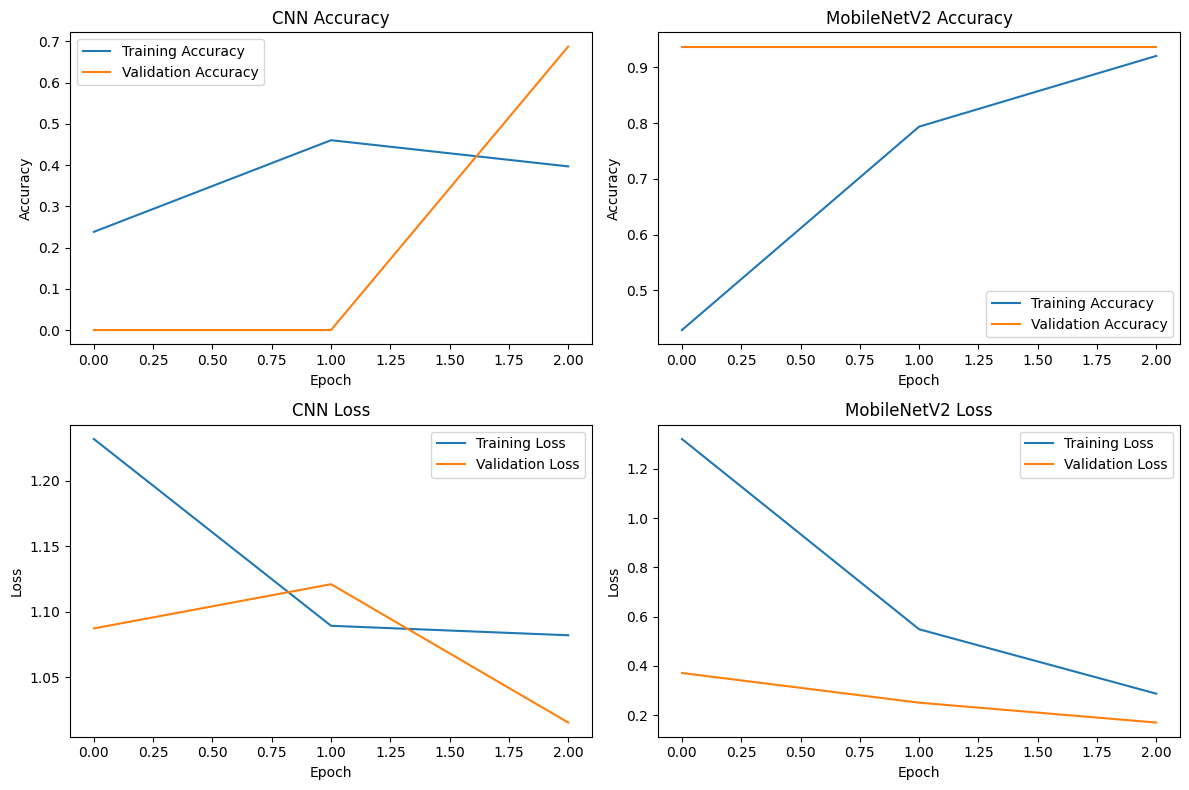


PROJECT COMPLETED
Classes: ['Early_blight', 'Late_blight', 'healthy']
CNN Accuracy: 100.0 %
MobileNetV2 Accuracy: 100.0 %


In [2]:
import os
import urllib.request
import json
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.utils import load_img, img_to_array
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow:", tf.__version__)

IMG_SIZE = (128, 128)
BATCH_SIZE = 16
EPOCHS = 3

DATA_DIR = "TomatoDisease"

classes = ["Early_blight", "Late_blight", "healthy"]

for c in classes:
    os.makedirs(os.path.join(DATA_DIR, c), exist_ok=True)


def download_class(c):

    api = f"https://api.github.com/repos/MAmudha/Tomato-leaf-disease-dataset/contents/{c}"

    req = urllib.request.Request(
        api,
        headers={"User-Agent": "Mozilla/5.0"}
    )

    with urllib.request.urlopen(req) as r:
        files = json.loads(r.read().decode())

    images = [
        f for f in files
        if f["name"].lower().endswith((".jpg", ".jpeg", ".png"))
    ][:30]

    def download(f):

        path = os.path.join(DATA_DIR, c, f["name"])

        if not os.path.exists(path):
            try:
                urllib.request.urlretrieve(
                    f["download_url"],
                    path
                )
            except:
                pass

    with ThreadPoolExecutor(max_workers=8) as ex:
        list(ex.map(download, images))

    print(c, ":", len(images), "images")


for c in classes:
    download_class(c)

print("Dataset ready")


train = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.30,
    subset="training",
    seed=123,
    shuffle=True
)

temp = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.30,
    subset="validation",
    seed=123,
    shuffle=False
)

class_names = train.class_names

n = tf.data.experimental.cardinality(temp).numpy()

val = temp.take(max(1, n // 2))
test = temp.skip(max(1, n // 2))

print("Classes:", class_names)
print("Train batches:", tf.data.experimental.cardinality(train).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val).numpy())
print("Test batches:", tf.data.experimental.cardinality(test).numpy())


plt.figure(figsize=(9, 6))

for images, labels in train.take(1):

    for i in range(min(6, len(images))):

        plt.subplot(2, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()


cnn = models.Sequential([
    layers.Rescaling(1./255, input_shape=(128, 128, 3)),
    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(3, activation="softmax")
])

cnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\nCNN TRAINING")

history_cnn = cnn.fit(
    train,
    validation_data=val,
    epochs=EPOCHS
)


base = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(128, 128, 3)
)

base.trainable = False

mobilenet = models.Sequential([
    layers.Input(shape=(128, 128, 3)),
    layers.Lambda(lambda x: preprocess_input(x)),
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(3, activation="softmax")
])

mobilenet.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\nMOBILENETV2 TRAINING")

history_mobile = mobilenet.fit(
    train,
    validation_data=val,
    epochs=EPOCHS
)


cnn_acc = cnn.evaluate(test, verbose=0)[1]
mobile_acc = mobilenet.evaluate(test, verbose=0)[1]

print("\nMODEL PERFORMANCE")
print("CNN Test Accuracy:", round(cnn_acc * 100, 2), "%")
print("MobileNetV2 Test Accuracy:", round(mobile_acc * 100, 2), "%")


plt.figure(figsize=(6, 5))

plt.bar(
    ["CNN", "MobileNetV2"],
    [cnn_acc * 100, mobile_acc * 100]
)

plt.xlabel("Model")
plt.ylabel("Test Accuracy (%)")
plt.title("CNN vs MobileNetV2")
plt.ylim(0, 100)
plt.show()


y_true = []
y_pred = []

for x, y in test:

    p = mobilenet.predict(x, verbose=0)

    y_true.extend(y.numpy())
    y_pred.extend(np.argmax(p, axis=1))


print("\nCLASSIFICATION REPORT")

print(
    classification_report(
        y_true,
        y_pred,
        labels=[0, 1, 2],
        target_names=class_names,
        zero_division=0
    )
)


cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1, 2]
)

plt.figure(figsize=(7, 6))

plt.imshow(cm)

plt.title("Confusion Matrix - MobileNetV2")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    range(3),
    class_names,
    rotation=45
)

plt.yticks(
    range(3),
    class_names
)

plt.colorbar()

plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 8))


plt.subplot(2, 2, 1)

plt.plot(
    history_cnn.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_cnn.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()


plt.subplot(2, 2, 2)

plt.plot(
    history_mobile.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_mobile.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("MobileNetV2 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()


plt.subplot(2, 2, 3)

plt.plot(
    history_cnn.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_cnn.history["val_loss"],
    label="Validation Loss"
)

plt.title("CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()


plt.subplot(2, 2, 4)

plt.plot(
    history_mobile.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_mobile.history["val_loss"],
    label="Validation Loss"
)

plt.title("MobileNetV2 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()


plt.tight_layout()
plt.show()


print("\nPROJECT COMPLETED")
print("Classes:", class_names)
print("CNN Accuracy:", round(cnn_acc * 100, 2), "%")
print("MobileNetV2 Accuracy:", round(mobile_acc * 100, 2), "%")